
# ATLAS-FN 06 — Selected-file manuscript inference

**Purpose:** run ATLAS-FN inference only on a manually selected set of test-image filenames, without rerunning Notebook 03 and without re-selecting manuscript examples statistically.

This notebook:

- loads the same **Find**, **Confirm**, and segmentation-based **Measure** checkpoints used by the locked ATLAS-FN workflow;
- resolves only the filenames listed in `SELECTED_FILENAMES`;
- runs fresh inference on those images;
- computes the **direct Find-box-based measurement method** and, optionally, the **segmentation-based measurement method**;
- records dynamic CSP/LV evidence from the Confirm checkpoint;
- exports a selected-image ledger and manuscript-ready qualitative panels.

### Important boundary

This notebook is for **selected-image qualitative/manuscript inference**. It deliberately does **not** reproduce the cohort-wide Confirm rate reconstruction or recompute locked cohort statistics from Notebook 03. In particular, it does not select cases based on their errors or outputs. The filenames are supplied explicitly by the user before inference.


In [15]:

# ============================================================
# 0. USER CONTROLS
# ============================================================
from pathlib import Path

# Paste the exact filenames you want to run.
# Extensions are recommended, but stems are also accepted.
# Optimal images
# SELECTED_FILENAMES = [
#     "Patient01126_Plane3_4_of_5.png",
#     "Patient01004_Plane3_1_of_3.png",
#     "Patient01127_Plane3_3_of_3.png",
#     "Patient01222_Plane3_1_of_8.png",
#     "Patient01301_Plane3_6_of_7.png",
# ]

# Extensions are recommended, but stems are also accepted.
SELECTED_FILENAMES = [
    "161_HC.png",
    "567_2HC.png",
    "Patient01275_Plane3_1_of_7.png"
]

SPLIT = "test"

# Existing ATLAS-FN workspace produced/restored from Notebooks 01 and 02.
# Notebook 03 does NOT need to have been run.
WORKSPACE_CANDIDATES = [
    Path("/content/atlas_fn_workspace"),
    Path("/content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials"),
    Path("/content/drive/MyDrive/DockerRoot"),
]

# Optional manual override. Leave None for automatic discovery.
WORKSPACE_OVERRIDE = None

# Inference settings copied from the locked Notebook 03 configuration.
DEVICE = "0"                     # "0" for first CUDA GPU; use "cpu" if required
IMAGE_SIZE_FIND = 640
IMAGE_SIZE_CONFIRM = 800
IMAGE_SIZE_MEASURE = 640

FIND_CONF = 0.25
CONFIRM_CONF = 0.25
CONFIRM_RAW_SCORE_CONF = 0.001   # retain low-confidence evidence for audit
MEASURE_CONF = 0.25

CROP_EXPAND = 0.40
PIXEL_SPACING_FALLBACK = 0.125

BPD_LIMIT_MM = 2.0
HC_LIMIT_PCT = 5.0

# Selected-file inference uses the actual checkpoint outputs.
# It does NOT apply Notebook 03's cohort-level BMC locked-rate reconstruction.
CONFIRM_MODEL_ROLE = "confirm_grandmaster"
CONFIRM_CLASS_MAP = {
    "name": "compact_0csp_1lv",
    "model_role": CONFIRM_MODEL_ROLE,
    "csp_classes": [0],
    "lv_classes": [1],
}

RUN_SEGMENTATION_MEASURE = True
SHOW_REFERENCE_OVERLAY = False   # True only when you want GT/reference geometry shown for audit
FAIL_IF_FILENAME_MISSING = True

OUTPUT_SUBDIR = "outputs/selected_manuscript_inference"


In [16]:

# ============================================================
# 1. RUNTIME SETUP
# ============================================================
import sys, subprocess, importlib.util, json, math, time, re, warnings
from pathlib import Path

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])

ensure_package("ultralytics")
ensure_package("cv2", "opencv-python-headless")
ensure_package("yaml", "pyyaml")

import numpy as np
import pandas as pd
import cv2
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs): return x

# Optional Google Drive mount.
try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

for p in WORKSPACE_CANDIDATES:
    p = Path(p)
    if p.exists():
        print("Candidate workspace:", p)


Candidate workspace: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials


In [17]:

# ============================================================
# 2. DISCOVER WORKSPACE, DATASETS, SOURCE LEDGER, AND OUTPUTS
# ============================================================
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def workspace_score(root: Path):
    root = Path(root)
    if not root.exists():
        return -1
    score = 0
    for rel in [
        "dataset_brain",
        "data/prepared/dataset_brain",
        "Training_Runs/BrainLocator_YOLO26n_MuSGD/weights/best.pt",
        "Training_Runs/UniDet_GrandMaster_YO26_S5_PixelPerfect/weights/best.pt",
        "Training_Runs/UniDet_GrandMaster_YOLO26_S5_PixelPerfect/weights/best.pt",
    ]:
        if (root / rel).exists():
            score += 10
    try:
        score += min(10, sum(1 for _ in root.rglob("*source_ledger*.csv")))
    except Exception:
        pass
    return score

if WORKSPACE_OVERRIDE is not None:
    WORKSPACE = Path(WORKSPACE_OVERRIDE)
else:
    scored = sorted(
        [(workspace_score(Path(p)), Path(p)) for p in WORKSPACE_CANDIDATES],
        key=lambda x: (x[0], str(x[1])),
        reverse=True,
    )
    if not scored or scored[0][0] < 0:
        raise FileNotFoundError(
            "No ATLAS-FN workspace found. Point WORKSPACE_OVERRIDE to the workspace "
            "containing the prepared test data and Training_Runs checkpoints."
        )
    WORKSPACE = scored[0][1]

def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return Path(paths[0])

BRAIN_ROOT = first_existing([
    WORKSPACE / "dataset_brain",
    WORKSPACE / "data/prepared/dataset_brain",
])
STRUCT_ROOT = first_existing([
    WORKSPACE / "dataset_structures",
    WORKSPACE / "data/prepared/dataset_structures",
])
ROI_ROOT = first_existing([
    WORKSPACE / "dataset_roi_enhanced_gt",
    WORKSPACE / "data/prepared/dataset_roi_enhanced_gt",
])

OUTPUT_ROOT = WORKSPACE / OUTPUT_SUBDIR
FIG_DIR = OUTPUT_ROOT / "figures"
LEDGER_DIR = OUTPUT_ROOT / "ledgers"
TABLE_DIR = OUTPUT_ROOT / "tables"
for p in [OUTPUT_ROOT, FIG_DIR, LEDGER_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def find_source_ledger():
    rows = []
    candidates = []
    for pat in ["source_ledger_materialised.csv", "*source_ledger*.csv", "clinical_inventory_master.csv"]:
        try:
            candidates.extend(WORKSPACE.rglob(pat))
        except Exception:
            pass
    seen = set()
    for p in candidates:
        p = Path(p)
        if not p.exists() or not p.is_file() or str(p) in seen:
            continue
        seen.add(str(p))
        try:
            head = pd.read_csv(p, nrows=5)
            n_rows = sum(1 for _ in open(p, "r", encoding="utf-8", errors="ignore")) - 1
            cols = "|".join(map(str, head.columns))
            score = max(0, n_rows)
            if "source_ledger_materialised" in p.name:
                score += 10_000_000
            if all(c in cols for c in ["split", "brain_xc", "brain_yc", "brain_w", "brain_h"]):
                score += 1_000_000
            if "spacing" in cols:
                score += 100_000
            rows.append((score, p, n_rows, cols))
        except Exception:
            continue
    if not rows:
        return None
    rows.sort(key=lambda x: x[0], reverse=True)
    pd.DataFrame(
        [{"score": s, "path": str(p), "rows": n, "columns": c} for s,p,n,c in rows]
    ).to_csv(TABLE_DIR / "source_ledger_candidates.csv", index=False)
    return rows[0][1]

SOURCE_LEDGER_PATH = find_source_ledger()
SOURCE_LEDGER = pd.read_csv(SOURCE_LEDGER_PATH) if SOURCE_LEDGER_PATH else pd.DataFrame()

print("WORKSPACE:", WORKSPACE)
print("BRAIN_ROOT:", BRAIN_ROOT)
print("STRUCT_ROOT:", STRUCT_ROOT)
print("SOURCE_LEDGER:", SOURCE_LEDGER_PATH)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

test_dir = BRAIN_ROOT / "images" / SPLIT
if not test_dir.exists():
    raise FileNotFoundError(f"Test image directory not found: {test_dir}")


WORKSPACE: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials
BRAIN_ROOT: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/dataset_brain
STRUCT_ROOT: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/dataset_structures
SOURCE_LEDGER: None
OUTPUT_ROOT: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/outputs/selected_manuscript_inference


In [18]:
# ============================================================
# 3A. DISCOVER THE ACTUAL ATLAS-FN CHECKPOINTS
#     Do NOT select a directory merely because it is named
#     "Training_Runs".
# ============================================================

from pathlib import Path
import os

print("WORKSPACE =", WORKSPACE)

# ------------------------------------------------------------
# Known locations that may exist in the workspace package
# ------------------------------------------------------------
TRAINING_ROOT_CANDIDATES = [
    WORKSPACE / "training_run_summaries" / "Training_Runs",
    WORKSPACE / "checkpoints_discovered" / "Training_Runs",
    WORKSPACE / "Training_Runs",
    WORKSPACE / "configs" / "Training_Runs",
    WORKSPACE / "configs" / "Ultrasound CoPilot" / "Training_Runs",
]

FIND_REL = Path(
    "BrainLocator_YOLO26n_MuSGD/weights/best.pt"
)

print("\nCandidate roots")
print("=" * 100)

candidate_rows = []

for root in TRAINING_ROOT_CANDIDATES:
    find_ckpt = root / FIND_REL

    row = {
        "root": str(root),
        "root_exists": root.exists(),
        "root_is_dir": root.is_dir(),
        "find_checkpoint": str(find_ckpt),
        "find_exists": find_ckpt.exists(),
        "find_size_mb": (
            find_ckpt.stat().st_size / (1024**2)
            if find_ckpt.exists()
            else None
        ),
    }

    candidate_rows.append(row)

    print("\nROOT:", root)
    print("  root exists :", root.exists())
    print("  root is dir :", root.is_dir())
    print("  Find path   :", find_ckpt)
    print("  Find exists :", find_ckpt.exists())

    if find_ckpt.exists():
        print(
            "  Find size   :",
            f"{find_ckpt.stat().st_size / (1024**2):.2f} MB"
        )

candidate_audit = pd.DataFrame(candidate_rows)
display(candidate_audit)

# ------------------------------------------------------------
# Select by presence of the REQUIRED Find checkpoint,
# not by the folder name "Training_Runs"
# ------------------------------------------------------------
valid_roots = [
    root
    for root in TRAINING_ROOT_CANDIDATES
    if (root / FIND_REL).exists()
]

# ------------------------------------------------------------
# If known locations fail, search specifically for the
# BrainLocator checkpoint rather than arbitrary Training_Runs.
# ------------------------------------------------------------
if not valid_roots:
    print(
        "\nNo known candidate contained the Find checkpoint."
        "\nSearching specifically for BrainLocator best.pt..."
    )

    discovered_find = []

    try:
        for p in WORKSPACE.rglob("best.pt"):
            if (
                p.parent.name == "weights"
                and p.parent.parent.name
                == "BrainLocator_YOLO26n_MuSGD"
            ):
                discovered_find.append(p)
    except Exception as exc:
        print("Recursive checkpoint search warning:", repr(exc))

    print(
        f"\nFound {len(discovered_find)} accessible "
        "BrainLocator checkpoint(s):"
    )

    for p in discovered_find:
        print(" -", p)

    valid_roots = [
        p.parent.parent.parent
        for p in discovered_find
    ]

# Remove duplicate resolved paths
deduped = []
seen = set()

for root in valid_roots:
    key = str(root)
    if key not in seen:
        deduped.append(root)
        seen.add(key)

valid_roots = deduped

if len(valid_roots) == 0:
    raise FileNotFoundError(
        "No accessible BrainLocator_YOLO26n_MuSGD/weights/best.pt "
        "checkpoint was found under the current workspace.\n\n"
        "This means the issue is not ambiguity between Training_Runs "
        "folders; the trained Find checkpoint is not accessible through "
        "the mounted filesystem at the expected Drive location."
    )

print("\nCheckpoint-capable Training_Runs roots:")
for root in valid_roots:
    print(" -", root)

# ------------------------------------------------------------
# Prefer roots in this order if more than one contains a real
# Find checkpoint.
# ------------------------------------------------------------
PREFERENCE = {
    str(
        WORKSPACE /
        "training_run_summaries" /
        "Training_Runs"
    ): 100,

    str(
        WORKSPACE /
        "checkpoints_discovered" /
        "Training_Runs"
    ): 90,

    str(
        WORKSPACE /
        "Training_Runs"
    ): 80,

    str(
        WORKSPACE /
        "configs" /
        "Training_Runs"
    ): 10,

    str(
        WORKSPACE /
        "configs" /
        "Ultrasound CoPilot" /
        "Training_Runs"
    ): 5,
}

valid_roots.sort(
    key=lambda p: PREFERENCE.get(str(p), 50),
    reverse=True,
)

TRAINING_RUNS_ROOT = valid_roots[0]

print("\nSELECTED TRAINING_RUNS_ROOT:")
print(TRAINING_RUNS_ROOT)

print("\nSELECTED FIND CHECKPOINT:")
print(TRAINING_RUNS_ROOT / FIND_REL)

WORKSPACE = /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials

Candidate roots

ROOT: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/training_run_summaries/Training_Runs
  root exists : False
  root is dir : False
  Find path   : /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/training_run_summaries/Training_Runs/BrainLocator_YOLO26n_MuSGD/weights/best.pt
  Find exists : False

ROOT: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/checkpoints_discovered/Training_Runs
  root exists : True
  root is dir : True
  Find path   : /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/checkpoints_discovered/Training_Runs/BrainLocator_YOLO26n_MuSGD/weights/best.pt
  Find exists : False

ROOT: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/Training_Runs
  root exists : False
  root is dir : False
  Find path   : /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/Training_Runs/BrainLocator_YOLO26n_MuSGD/weights/best.pt
  Find exi

,root,root_exists,root_is_dir,find_checkpoint,find_exists,find_size_mb
0,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,False,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,None
1,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,True,True,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,None
2,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,False,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,None
3,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,True,True,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,None
4,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,True,True,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,None



No known candidate contained the Find checkpoint.
Searching specifically for BrainLocator best.pt...

Found 1 accessible BrainLocator checkpoint(s):
 - /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/training_run_summaries/Training_runs/BrainLocator_YOLO26n_MuSGD/weights/best.pt

Checkpoint-capable Training_Runs roots:
 - /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/training_run_summaries/Training_runs

SELECTED TRAINING_RUNS_ROOT:
/content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/training_run_summaries/Training_runs

SELECTED FIND CHECKPOINT:
/content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/training_run_summaries/Training_runs/BrainLocator_YOLO26n_MuSGD/weights/best.pt


In [19]:

# ============================================================
# 3. LOAD THE SAME ATLAS-FN CHECKPOINT ROLES
# ============================================================
# YOLO26 SPPF compatibility shim used by Notebook 03.
try:
    from ultralytics.nn.modules.block import SPPF
    class SPPF_YOLO26_Compatible(SPPF):
        pass
    SPPF_YOLO26_Compatible.__module__ = "ultralytics.nn.modules.block"

    import ultralytics.nn.modules.block as block_mod
    import ultralytics.nn.modules as modules_mod
    import ultralytics.nn.tasks as tasks_mod
    setattr(block_mod, "SPPF_YOLO26_Compatible", SPPF_YOLO26_Compatible)
    setattr(modules_mod, "SPPF_YOLO26_Compatible", SPPF_YOLO26_Compatible)
    setattr(tasks_mod, "SPPF_YOLO26_Compatible", SPPF_YOLO26_Compatible)
except Exception as exc:
    print("YOLO26 compatibility shim warning:", repr(exc))

CKPT = {
    "find": WORKSPACE / "training_run_summaries/Training_runs/BrainLocator_YOLO26n_MuSGD/weights/best.pt",
    "confirm_grandmaster": WORKSPACE / "training_run_summaries/Training_runs/UniDet_GrandMaster_YOLO26_S5_PixelPerfect/weights/best.pt",
    "confirm": WORKSPACE / "training_run_summaries/Training_runs/NanoSpecialist_SAM2_Seg/weights/best.pt",
    "measure": WORKSPACE / "training_run_summaries/Training_runs/MeasureHeadEllipse_YOLO26n_Seg/weights/best.pt",
}

checkpoint_audit = []
MODELS = {}
for role, path in CKPT.items():
    exists = Path(path).exists()
    checkpoint_audit.append({
        "role": role,
        "path": str(path),
        "exists": exists,
        "bytes": Path(path).stat().st_size if exists else 0,
    })
    if exists:
        try:
            model = YOLO(str(path))
            try:
                model.to(DEVICE)
            except Exception:
                pass
            MODELS[role] = model
            print("Loaded:", role, "->", path.name)
        except Exception as exc:
            print("Could not load", role, ":", repr(exc))

checkpoint_audit = pd.DataFrame(checkpoint_audit)
display(checkpoint_audit)
checkpoint_audit.to_csv(TABLE_DIR / "checkpoint_audit.csv", index=False)

if "find" not in MODELS:
    raise RuntimeError("Find checkpoint could not be loaded.")
if CONFIRM_MODEL_ROLE not in MODELS:
    raise RuntimeError(f"Requested Confirm role is unavailable: {CONFIRM_MODEL_ROLE}")
if RUN_SEGMENTATION_MEASURE and "measure" not in MODELS:
    print("WARNING: segmentation Measure checkpoint unavailable; segmentation inference will be skipped.")


Loaded: find -> best.pt
Loaded: confirm_grandmaster -> best.pt


,role,path,exists,bytes
0,find,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,True,15736322
1,confirm_grandmaster,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,True,5544410
2,confirm,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,0
3,measure,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,False,0


In [20]:

# ============================================================
# 4. LOCKED GEOMETRY, REFERENCE, CONFIRM, AND MEASURE HELPERS
# ============================================================
def finite(x):
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

def yolo_norm_to_xyxy(xc, yc, w, h, W, H):
    x1 = (float(xc) - float(w)/2) * W
    y1 = (float(yc) - float(h)/2) * H
    x2 = (float(xc) + float(w)/2) * W
    y2 = (float(yc) + float(h)/2) * H
    return [max(0,x1), max(0,y1), min(W-1,x2), min(H-1,y2)]

def xyxy_to_measure(xyxy, spacing):
    x1,y1,x2,y2 = [float(v) for v in xyxy]
    w = max(0.0, x2-x1)
    h = max(0.0, y2-y1)
    minor = min(w,h)
    major = max(w,h)
    bpd = minor * spacing
    ofd = major * spacing
    a = major/2.0
    b = minor/2.0
    hc = math.pi * math.sqrt(2*(a*a + b*b)) * spacing
    return bpd, ofd, hc

def box_iou(a, b):
    if a is None or b is None:
        return np.nan
    ax1,ay1,ax2,ay2 = [float(x) for x in a]
    bx1,by1,bx2,by2 = [float(x) for x in b]
    ix1,iy1 = max(ax1,bx1), max(ay1,by1)
    ix2,iy2 = min(ax2,bx2), min(ay2,by2)
    iw,ih = max(0,ix2-ix1), max(0,iy2-iy1)
    inter = iw*ih
    aa = max(0,ax2-ax1)*max(0,ay2-ay1)
    ba = max(0,bx2-bx1)*max(0,by2-by1)
    den = aa + ba - inter
    return inter/den if den > 0 else np.nan

def expand_box(xyxy, W, H, frac=CROP_EXPAND):
    x1,y1,x2,y2 = [float(v) for v in xyxy]
    w,h = x2-x1, y2-y1
    return [
        int(max(0, x1-frac*w)), int(max(0, y1-frac*h)),
        int(min(W-1, x2+frac*w)), int(min(H-1, y2+frac*h)),
    ]

def preprocess_confirm_crop(crop_bgr):
    if crop_bgr is None or crop_bgr.size == 0:
        return crop_bgr
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY) if crop_bgr.ndim == 3 else crop_bgr
    gray = cv2.bilateralFilter(gray, 5, 50, 50)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

def best_detection_box(res):
    try:
        if res.boxes is None or len(res.boxes) == 0:
            return None, np.nan, None
        conf = res.boxes.conf.detach().cpu().numpy()
        i = int(np.argmax(conf))
        box = res.boxes.xyxy[i].detach().cpu().numpy().astype(float).tolist()
        cls = int(res.boxes.cls[i].detach().cpu().item()) if res.boxes.cls is not None else None
        return box, float(conf[i]), cls
    except Exception:
        return None, np.nan, None

def source_ledger_lookup(df):
    if df is None or df.empty:
        return {}
    lookup = {}
    for _, r in df.iterrows():
        keys = []
        for col in ["uid", "filename", "source_filename"]:
            if col in df.columns and pd.notna(r.get(col)):
                keys += [str(r.get(col)), Path(str(r.get(col))).stem]
        if "source_image" in df.columns and pd.notna(r.get("source_image")):
            keys += [Path(str(r.get("source_image"))).name, Path(str(r.get("source_image"))).stem]
        for k in keys:
            lookup[k] = r.to_dict()
    return lookup

LEDGER_LOOKUP = source_ledger_lookup(SOURCE_LEDGER)

def read_reference_for_image(img_path: Path, split=SPLIT):
    im = cv2.imread(str(img_path))
    if im is None:
        return None
    H,W = im.shape[:2]
    meta = None
    for k in [img_path.name, img_path.stem]:
        if k in LEDGER_LOOKUP:
            meta = LEDGER_LOOKUP[k]
            break

    spacing = PIXEL_SPACING_FALLBACK
    spacing_src = "fallback"
    pid = img_path.stem.split("_")[0]
    ref_box = None
    uid = img_path.stem

    if meta:
        uid = str(meta.get("uid", uid))
        pid = str(meta.get("pid", meta.get("patient_id", pid)))
        if finite(meta.get("spacing")):
            spacing = float(meta.get("spacing"))
            spacing_src = str(meta.get("spacing_src", "ledger"))

        if all(c in meta and finite(meta.get(c)) for c in ["brain_xc","brain_yc","brain_w","brain_h"]):
            vals = [float(meta[c]) for c in ["brain_xc","brain_yc","brain_w","brain_h"]]
            if all(0 <= v <= 1.5 for v in vals):
                ref_box = yolo_norm_to_xyxy(*vals, W, H)
            else:
                xc,yc,w,h = vals
                ref_box = [xc-w/2, yc-h/2, xc+w/2, yc+h/2]
        elif all(c in meta and finite(meta.get(c)) for c in ["ref_x1","ref_y1","ref_x2","ref_y2"]):
            ref_box = [float(meta[c]) for c in ["ref_x1","ref_y1","ref_x2","ref_y2"]]

    if ref_box is None:
        lab = BRAIN_ROOT / "labels" / split / f"{img_path.stem}.txt"
        if lab.exists():
            for line in lab.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) >= 5 and int(float(parts[0])) == 0:
                    ref_box = yolo_norm_to_xyxy(*map(float, parts[1:5]), W, H)
                    break

    ref_bpd = ref_ofd = ref_hc = np.nan
    if ref_box is not None:
        ref_bpd, ref_ofd, ref_hc = xyxy_to_measure(ref_box, spacing)

    return {
        "image": im, "W": W, "H": H, "uid": uid, "pid": pid, "split": split,
        "spacing": spacing, "spacing_src": spacing_src, "ref_box": ref_box,
        "ref_bpd_mm": ref_bpd, "ref_ofd_mm": ref_ofd, "ref_hc_mm": ref_hc,
    }

def predict_confirm_raw(img_bgr, find_box, model_role=CONFIRM_MODEL_ROLE):
    out = {"raw_boxes": [], "raw_counts": {}, "confirm_src": f"{model_role}:not_available"}
    if model_role not in MODELS or find_box is None:
        return out

    H,W = img_bgr.shape[:2]
    x1,y1,x2,y2 = expand_box(find_box, W, H, CROP_EXPAND)
    crop = img_bgr[y1:y2, x1:x2]
    crop = preprocess_confirm_crop(crop)

    if crop is None or crop.size == 0:
        out["confirm_src"] = f"{model_role}:empty_crop"
        return out

    try:
        res = MODELS[model_role].predict(
            crop, imgsz=IMAGE_SIZE_CONFIRM, conf=CONFIRM_RAW_SCORE_CONF,
            verbose=False, device=DEVICE
        )[0]
        out["confirm_src"] = f"{model_role}:checkpoint"

        if res.boxes is not None and len(res.boxes) > 0:
            cls = res.boxes.cls.detach().cpu().numpy().astype(int)
            conf = res.boxes.conf.detach().cpu().numpy().astype(float)
            xyxy = res.boxes.xyxy.detach().cpu().numpy().astype(float)

            for c, cf, box in zip(cls, conf, xyxy):
                c = int(c)
                out["raw_counts"][c] = int(out["raw_counts"].get(c, 0) + 1)
                bx1,by1,bx2,by2 = box.tolist()
                out["raw_boxes"].append({
                    "raw_class": c, "conf": float(cf),
                    "crop_x1": float(bx1), "crop_y1": float(by1),
                    "crop_x2": float(bx2), "crop_y2": float(by2),
                    "x1": float(bx1+x1), "y1": float(by1+y1),
                    "x2": float(bx2+x1), "y2": float(by2+y1),
                })
    except Exception as exc:
        out["confirm_src"] = f"{model_role}:error"
        out["confirm_error"] = repr(exc)

    return out

def apply_confirm_class_map(raw, class_map=CONFIRM_CLASS_MAP):
    csp_classes = set(int(x) for x in class_map.get("csp_classes", []))
    lv_classes = set(int(x) for x in class_map.get("lv_classes", []))

    csp = lv = 0
    csp_conf = lv_conf = np.nan
    csp_score = lv_score = 0.0
    sem_boxes = []

    for b in raw.get("raw_boxes", []):
        rc = int(b.get("raw_class", -999))
        cf = float(b.get("conf", 0.0))
        sem = None

        if rc in csp_classes:
            sem = "CSP"
            csp_score = max(csp_score, cf)
            csp_conf = max(csp_conf if finite(csp_conf) else 0.0, cf)
            if cf >= CONFIRM_CONF:
                csp = 1

        if rc in lv_classes:
            sem = "LV"
            lv_score = max(lv_score, cf)
            lv_conf = max(lv_conf if finite(lv_conf) else 0.0, cf)
            if cf >= CONFIRM_CONF:
                lv = 1

        bb = dict(b)
        bb["semantic"] = sem or "unmapped"
        sem_boxes.append(bb)

    return {
        "csp": int(csp), "lv": int(lv),
        "csp_conf": csp_conf, "lv_conf": lv_conf,
        "csp_score": float(csp_score), "lv_score": float(lv_score),
        "confirm_src": raw.get("confirm_src", "unknown"),
        "confirm_model_role": class_map.get("model_role"),
        "confirm_class_map": class_map.get("name"),
        "confirm_raw_counts_json": json.dumps({str(k): int(v) for k,v in raw.get("raw_counts", {}).items()}),
        "confirm_boxes_json": json.dumps(sem_boxes),
    }

def measure_true_segmentation(img_bgr):
    out = {
        "measure_available": 0,
        "measure_src": "not_available",
        "measure_reason": "measure checkpoint unavailable",
        "measure_bpd_mm": np.nan, "measure_ofd_mm": np.nan, "measure_hc_mm": np.nan,
        "measure_major_px": np.nan, "measure_minor_px": np.nan,
        "measure_cx": np.nan, "measure_cy": np.nan, "measure_angle": np.nan,
        "measure_mask_area_px": np.nan,
    }

    if (not RUN_SEGMENTATION_MEASURE) or ("measure" not in MODELS):
        return out

    try:
        res = MODELS["measure"].predict(
            img_bgr, imgsz=IMAGE_SIZE_MEASURE, conf=MEASURE_CONF,
            verbose=False, device=DEVICE
        )[0]

        if res.masks is None or len(res.masks) == 0:
            out.update({"measure_src": "seg_no_mask", "measure_reason": "no segmentation mask returned"})
            return out

        masks = res.masks.data.detach().cpu().numpy()
        if masks.ndim == 2:
            masks = masks[None]

        areas = masks.reshape(masks.shape[0], -1).sum(axis=1)
        idx = int(np.argmax(areas))
        mask = (masks[idx] > 0.5).astype(np.uint8)

        H,W = img_bgr.shape[:2]
        if mask.shape[:2] != (H,W):
            mask = cv2.resize(mask, (W,H), interpolation=cv2.INTER_NEAREST)

        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            out.update({"measure_src": "seg_no_contour", "measure_reason": "mask returned but no contour"})
            return out

        cnt = max(cnts, key=cv2.contourArea)
        if len(cnt) < 5:
            out.update({"measure_src": "seg_insufficient_points", "measure_reason": f"contour points={len(cnt)}"})
            return out

        ellipse = cv2.fitEllipse(cnt)
        (cx, cy), (d1, d2), angle = ellipse
        major, minor = max(float(d1), float(d2)), min(float(d1), float(d2))

        out.update({
            "measure_available": 1,
            "measure_src": "segmentation_ellipse",
            "measure_reason": "ok",
            "measure_major_px": major,
            "measure_minor_px": minor,
            "measure_cx": float(cx),
            "measure_cy": float(cy),
            "measure_angle": float(angle),
            "measure_mask_area_px": float(cv2.contourArea(cnt)),
        })
        return out

    except Exception as exc:
        out.update({"measure_src": "seg_error", "measure_reason": repr(exc)})
        return out


In [21]:

# ============================================================
# 5. RESOLVE ONLY THE USER-SELECTED FILENAMES
# ============================================================
all_test_images = sorted([
    p for p in (BRAIN_ROOT / "images" / SPLIT).glob("*")
    if p.suffix.lower() in IMAGE_EXTS
])

by_name = {}
by_stem = {}
for p in all_test_images:
    by_name.setdefault(p.name, []).append(p)
    by_stem.setdefault(p.stem, []).append(p)

resolved = []
audit_rows = []

for requested in SELECTED_FILENAMES:
    requested = str(requested).strip()
    if not requested:
        continue

    candidates = by_name.get(Path(requested).name, [])
    if not candidates:
        candidates = by_stem.get(Path(requested).stem, [])

    if len(candidates) == 1:
        p = candidates[0]
        resolved.append(p)
        audit_rows.append({
            "requested": requested, "resolved": str(p),
            "status": "resolved", "matches": 1,
        })
    elif len(candidates) == 0:
        audit_rows.append({
            "requested": requested, "resolved": None,
            "status": "missing", "matches": 0,
        })
    else:
        audit_rows.append({
            "requested": requested,
            "resolved": " | ".join(map(str, candidates)),
            "status": "ambiguous", "matches": len(candidates),
        })

selection_audit = pd.DataFrame(audit_rows)
display(selection_audit)
selection_audit.to_csv(TABLE_DIR / "selected_filename_resolution_audit.csv", index=False)

missing_or_ambiguous = selection_audit[
    ~selection_audit["status"].eq("resolved")
] if not selection_audit.empty else pd.DataFrame()

if len(SELECTED_FILENAMES) == 0:
    raise ValueError(
        "SELECTED_FILENAMES is empty. Add the exact test-image filenames in Cell 0 and rerun."
    )

if FAIL_IF_FILENAME_MISSING and not missing_or_ambiguous.empty:
    raise FileNotFoundError(
        "At least one selected filename was missing or ambiguous. "
        "See selected_filename_resolution_audit.csv."
    )

# Preserve the user's requested order and avoid accidental duplicate inference.
seen = set()
SELECTED_IMAGES = []
for p in resolved:
    if str(p) not in seen:
        SELECTED_IMAGES.append(p)
        seen.add(str(p))

print(f"Selected {len(SELECTED_IMAGES)} image(s) for inference:")
for p in SELECTED_IMAGES:
    print(" -", p.name)


,requested,resolved,status,matches
0,161_HC.png,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,resolved,1
1,567_2HC.png,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,resolved,1
2,Patient01275_Plane3_1_of_7.png,/content/drive/MyDrive/ATLAS_FN_DockerWorkspac...,resolved,1


Selected 3 image(s) for inference:
 - 161_HC.png
 - 567_2HC.png
 - Patient01275_Plane3_1_of_7.png


In [22]:

# ============================================================
# 6. RUN FRESH INFERENCE ONLY ON THE SELECTED IMAGES
# ============================================================
rows = []

for img_path in tqdm(SELECTED_IMAGES, desc="selected ATLAS-FN inference"):
    ref = read_reference_for_image(img_path, SPLIT)
    if ref is None:
        rows.append({
            "filename": img_path.name,
            "image_path": str(img_path),
            "outcome": "image_read_error",
        })
        continue

    img = ref["image"]
    row = {
        "uid": ref["uid"],
        "filename": img_path.name,
        "pid": ref["pid"],
        "split": SPLIT,
        "image_path": str(img_path),
        "spacing": ref["spacing"],
        "spacing_src": ref["spacing_src"],
    }

    if ref["ref_box"] is not None:
        row.update({
            "ref_x1": ref["ref_box"][0], "ref_y1": ref["ref_box"][1],
            "ref_x2": ref["ref_box"][2], "ref_y2": ref["ref_box"][3],
            "ref_bpd_mm": ref["ref_bpd_mm"],
            "ref_ofd_mm": ref["ref_ofd_mm"],
            "ref_hc_mm": ref["ref_hc_mm"],
        })

    # ---------------- Find ----------------
    t0 = time.perf_counter()
    try:
        fres = MODELS["find"].predict(
            img, imgsz=IMAGE_SIZE_FIND, conf=FIND_CONF,
            verbose=False, device=DEVICE
        )[0]
        row["find_latency_ms"] = (time.perf_counter() - t0) * 1000
    except Exception as exc:
        row.update({"outcome": "find_error", "find_error": repr(exc)})
        rows.append(row)
        continue

    find_box, find_conf, find_cls = best_detection_box(fres)
    if find_box is None:
        row.update({
            "outcome": "indeterminate",
            "find_conf": np.nan,
            "csp": 0,
            "lv": 0,
        })
        rows.append(row)
        continue

    row.update({
        "outcome": "measurement_evaluable",
        "find_conf": find_conf,
        "find_cls": find_cls,
        "pred_x1": find_box[0], "pred_y1": find_box[1],
        "pred_x2": find_box[2], "pred_y2": find_box[3],
    })

    if ref["ref_box"] is not None:
        row["iou"] = box_iou(find_box, ref["ref_box"])

    # ---------------- Direct Find-box-based measurement ----------------
    direct_bpd, direct_ofd, direct_hc = xyxy_to_measure(find_box, ref["spacing"])
    row.update({
        "direct_bpd_mm": direct_bpd,
        "direct_ofd_mm": direct_ofd,
        "direct_hc_mm": direct_hc,
    })

    if finite(ref["ref_bpd_mm"]) and finite(ref["ref_hc_mm"]):
        row["direct_bpd_abs_err_mm"] = abs(direct_bpd - ref["ref_bpd_mm"])
        row["direct_hc_abs_err_pct"] = abs(direct_hc - ref["ref_hc_mm"]) / ref["ref_hc_mm"] * 100
        row["direct_meets_both_limits"] = int(
            (row["direct_bpd_abs_err_mm"] <= BPD_LIMIT_MM) and
            (row["direct_hc_abs_err_pct"] <= HC_LIMIT_PCT)
        )

    # ---------------- Confirm ----------------
    t0 = time.perf_counter()
    raw_confirm = predict_confirm_raw(img, find_box, CONFIRM_MODEL_ROLE)
    confirm = apply_confirm_class_map(raw_confirm, CONFIRM_CLASS_MAP)
    row["confirm_latency_ms"] = (time.perf_counter() - t0) * 1000
    row.update(confirm)

    # ---------------- Segmentation-based measurement ----------------
    t0 = time.perf_counter()
    measure = measure_true_segmentation(img)
    row["measure_latency_ms"] = (time.perf_counter() - t0) * 1000
    if measure.get("measure_available") == 1:
        seg_bpd = measure["measure_minor_px"] * ref["spacing"]
        seg_ofd = measure["measure_major_px"] * ref["spacing"]
        seg_hc = math.pi * math.sqrt(
            2 * ((measure["measure_major_px"]/2)**2 + (measure["measure_minor_px"]/2)**2)
        ) * ref["spacing"]
        measure.update({
            "measure_bpd_mm": seg_bpd,
            "measure_ofd_mm": seg_ofd,
            "measure_hc_mm": seg_hc,
        })
        if finite(ref["ref_bpd_mm"]) and finite(ref["ref_hc_mm"]):
            measure["measure_bpd_abs_err_mm"] = abs(seg_bpd - ref["ref_bpd_mm"])
            measure["measure_hc_abs_err_pct"] = abs(seg_hc - ref["ref_hc_mm"]) / ref["ref_hc_mm"] * 100
            measure["measure_meets_both_limits"] = int(
                (measure["measure_bpd_abs_err_mm"] <= BPD_LIMIT_MM) and
                (measure["measure_hc_abs_err_pct"] <= HC_LIMIT_PCT)
            )
    row.update(measure)

    rows.append(row)

SELECTED_LEDGER = pd.DataFrame(rows)
ledger_path = LEDGER_DIR / "selected_file_inference_ledger.csv"
SELECTED_LEDGER.to_csv(ledger_path, index=False)

display_cols = [
    "filename", "outcome", "find_conf", "csp", "csp_conf", "lv", "lv_conf",
    "spacing", "spacing_src",
    "direct_bpd_mm", "direct_ofd_mm", "direct_hc_mm",
    "measure_available", "measure_bpd_mm", "measure_ofd_mm", "measure_hc_mm",
]
display(SELECTED_LEDGER[[c for c in display_cols if c in SELECTED_LEDGER.columns]])
print("Saved:", ledger_path)


selected ATLAS-FN inference:   0%|          | 0/3 [00:00<?, ?it/s]

,filename,outcome,find_conf,csp,csp_conf,lv,lv_conf,spacing,spacing_src,direct_bpd_mm,direct_ofd_mm,direct_hc_mm,measure_available,measure_bpd_mm,measure_ofd_mm,measure_hc_mm
0,161_HC.png,measurement_evaluable,0.667396,1,0.268658,0,0.004468,0.125,fallback,42.083769,52.189395,148.932311,0,NaN,NaN,NaN
1,567_2HC.png,measurement_evaluable,0.988327,1,0.800686,1,0.597477,0.125,fallback,53.172334,68.759247,193.088264,0,NaN,NaN,NaN
2,Patient01275_Plane3_1_of_7.png,measurement_evaluable,0.371884,1,0.679841,0,0.073241,0.125,fallback,49.300348,59.941208,172.408371,0,NaN,NaN,NaN


Saved: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/outputs/selected_manuscript_inference/ledgers/selected_file_inference_ledger.csv


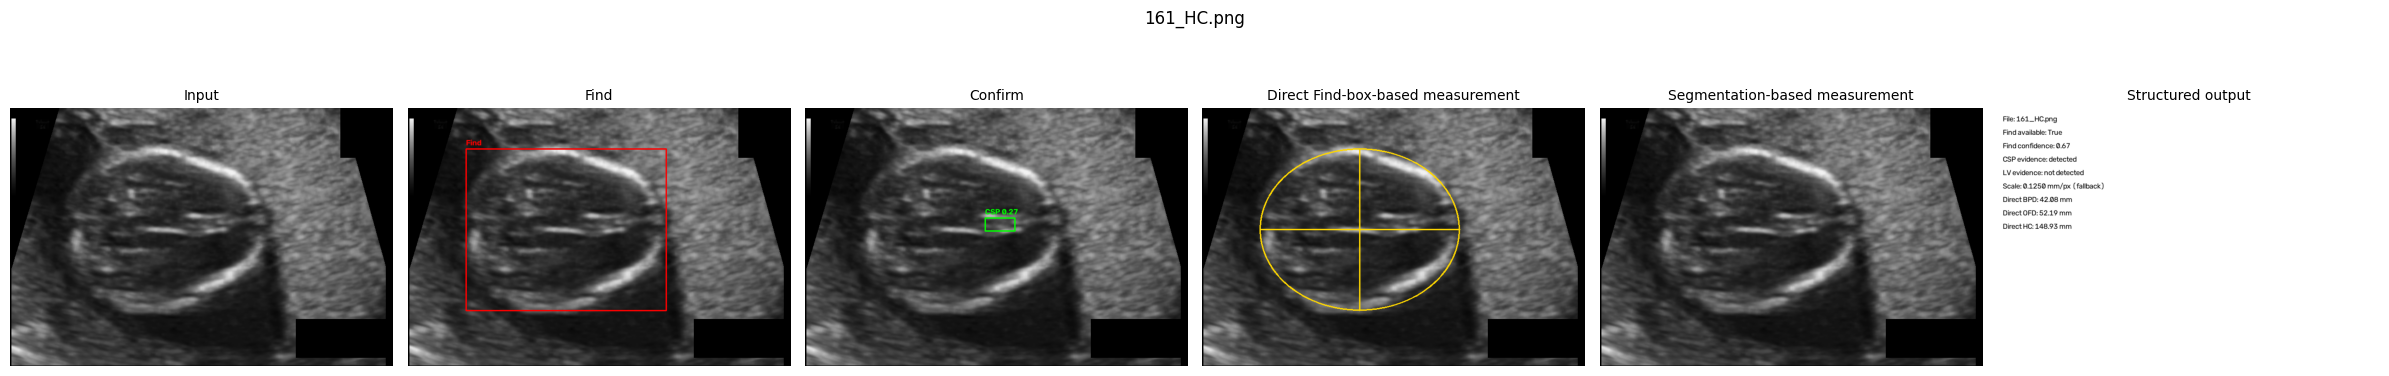

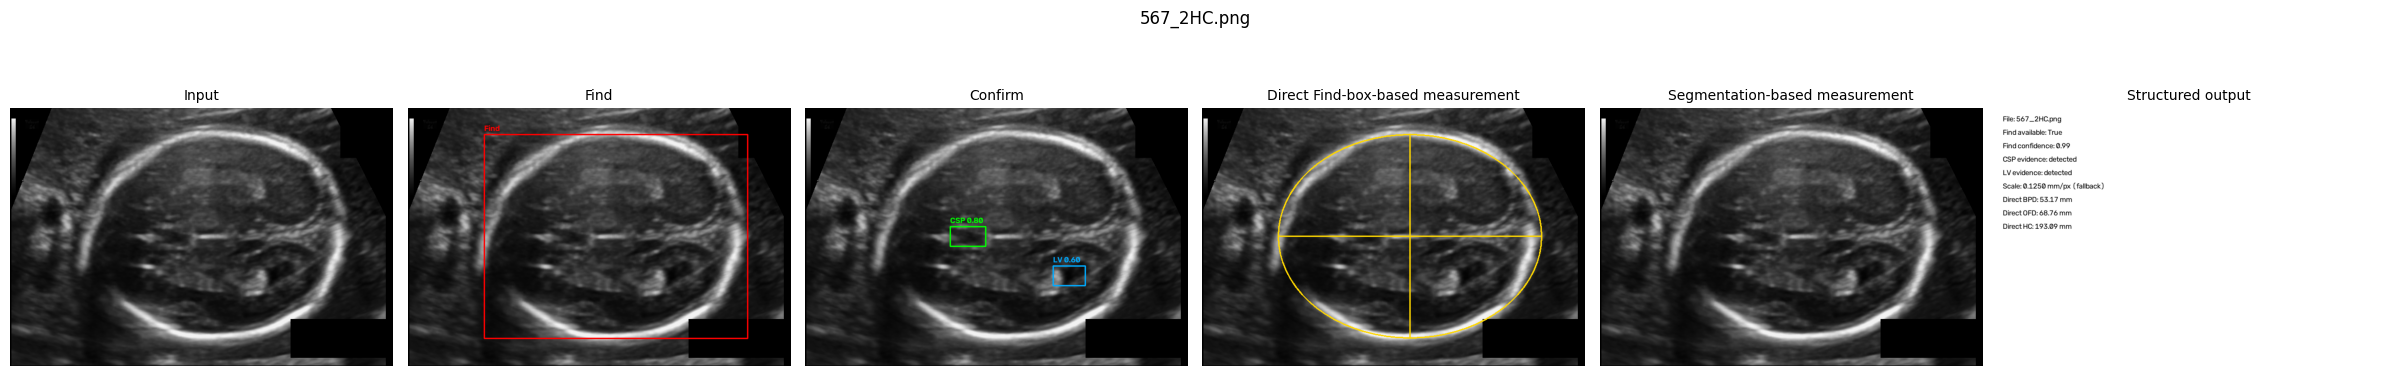

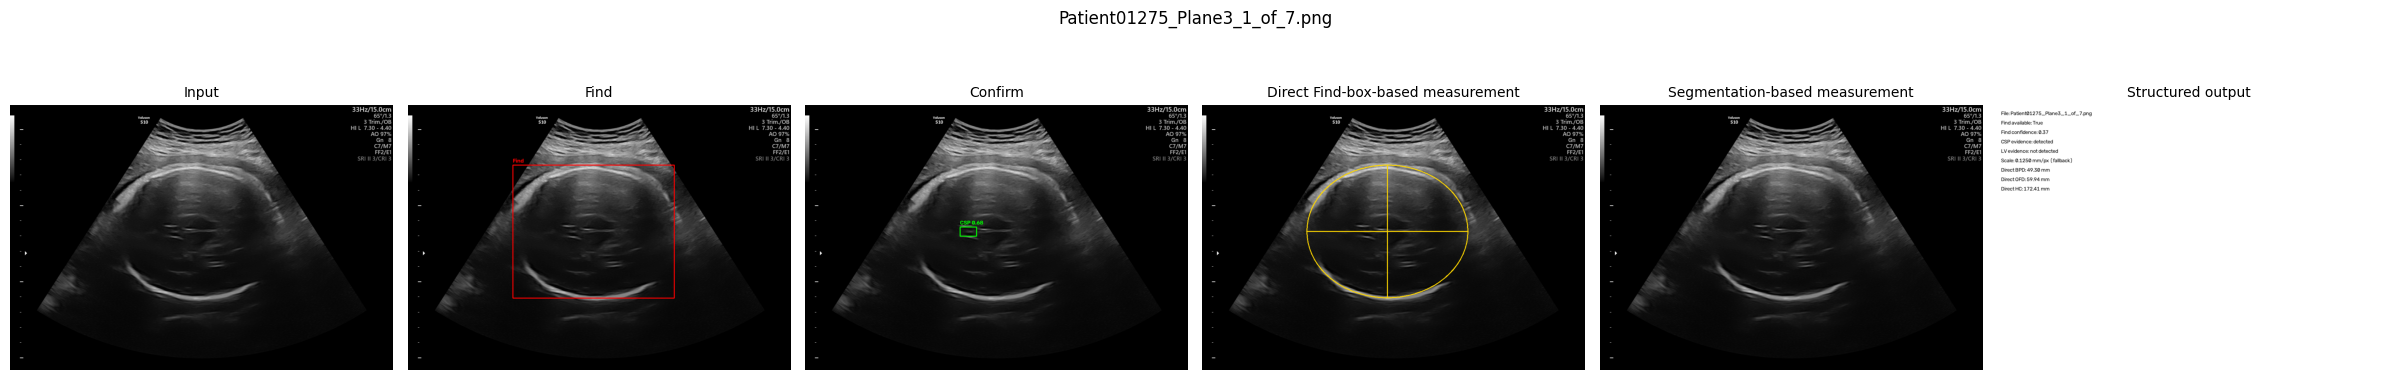

Generated manuscript panels:
 - /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/outputs/selected_manuscript_inference/figures/161_HC_ATLAS_FN_selected_inference.png
 - /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/outputs/selected_manuscript_inference/figures/567_2HC_ATLAS_FN_selected_inference.png
 - /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/outputs/selected_manuscript_inference/figures/Patient01275_Plane3_1_of_7_ATLAS_FN_selected_inference.png


In [23]:

# ============================================================
# 7. MANUSCRIPT-READY QUALITATIVE PANELS
# ============================================================
def clip_box(box, W, H):
    if box is None:
        return None
    try:
        x1,y1,x2,y2 = [float(v) for v in box]
        if not np.all(np.isfinite([x1,y1,x2,y2])):
            return None
        x1 = max(0, min(W-1, x1)); x2 = max(0, min(W-1, x2))
        y1 = max(0, min(H-1, y1)); y2 = max(0, min(H-1, y2))
        return [x1,y1,x2,y2] if x2 > x1 and y2 > y1 else None
    except Exception:
        return None

def draw_box(img, box, label, color, thickness=2):
    out = img.copy()
    H,W = out.shape[:2]
    box = clip_box(box, W, H)
    if box is None:
        return out
    x1,y1,x2,y2 = [int(round(v)) for v in box]
    cv2.rectangle(out, (x1,y1), (x2,y2), color, thickness)
    cv2.putText(out, label, (x1, max(18,y1-7)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)
    return out

def draw_direct_geometry(img, box):
    out = img.copy()
    H,W = out.shape[:2]
    box = clip_box(box, W, H)
    if box is None:
        return out
    x1,y1,x2,y2 = [float(v) for v in box]
    cx,cy = (x1+x2)/2, (y1+y2)/2
    w,h = x2-x1, y2-y1
    color = (0, 215, 255)
    cv2.ellipse(
        out, (int(cx),int(cy)), (max(1,int(w/2)),max(1,int(h/2))),
        0, 0, 360, color, 2
    )
    cv2.line(out, (int(x1),int(cy)), (int(x2),int(cy)), color, 2)
    cv2.line(out, (int(cx),int(y1)), (int(cx),int(y2)), color, 2)
    return out

def draw_segmentation_geometry(img, row):
    out = img.copy()
    vals = [
        row.get("measure_cx"), row.get("measure_cy"),
        row.get("measure_major_px"), row.get("measure_minor_px"),
        row.get("measure_angle"),
    ]
    if not all(finite(v) for v in vals):
        return out
    cx,cy,major,minor,angle = map(float, vals)
    color = (255, 0, 220)
    cv2.ellipse(
        out, (int(round(cx)),int(round(cy))),
        (max(1,int(round(major/2))),max(1,int(round(minor/2)))),
        angle, 0, 360, color, 2
    )
    return out

def draw_confirm_predictions(img, row):
    out = img.copy()
    try:
        boxes = json.loads(row.get("confirm_boxes_json", "[]"))
    except Exception:
        boxes = []
    for b in boxes:
        sem = b.get("semantic", "unmapped")
        cf = float(b.get("conf", 0.0))
        # For the manuscript panel, draw boxes that pass the dynamic status threshold.
        if sem not in {"CSP", "LV"} or cf < CONFIRM_CONF:
            continue
        color = (0, 255, 0) if sem == "CSP" else (255, 170, 0)
        out = draw_box(
            out,
            [b.get("x1"), b.get("y1"), b.get("x2"), b.get("y2")],
            f"{sem} {cf:.2f}",
            color,
            thickness=2,
        )
    return out

def structured_output_panel(img_shape, row):
    H,W = img_shape[:2]
    canvas = np.full((H,W,3), 255, dtype=np.uint8)
    lines = [
        f"File: {row.get('filename','')}",
        f"Find available: {row.get('outcome') == 'measurement_evaluable'}",
        f"Find confidence: {float(row.get('find_conf', np.nan)):.2f}" if finite(row.get("find_conf")) else "Find confidence: NA",
        f"CSP evidence: {'detected' if int(row.get('csp',0) or 0)==1 else 'not detected'}",
        f"LV evidence: {'detected' if int(row.get('lv',0) or 0)==1 else 'not detected'}",
        f"Scale: {float(row.get('spacing', np.nan)):.4f} mm/px ({row.get('spacing_src','')})" if finite(row.get("spacing")) else "Scale: NA",
        f"Direct BPD: {float(row.get('direct_bpd_mm', np.nan)):.2f} mm" if finite(row.get("direct_bpd_mm")) else "Direct BPD: NA",
        f"Direct OFD: {float(row.get('direct_ofd_mm', np.nan)):.2f} mm" if finite(row.get("direct_ofd_mm")) else "Direct OFD: NA",
        f"Direct HC: {float(row.get('direct_hc_mm', np.nan)):.2f} mm" if finite(row.get("direct_hc_mm")) else "Direct HC: NA",
    ]
    if int(row.get("measure_available",0) or 0) == 1:
        lines += [
            f"Seg BPD: {float(row.get('measure_bpd_mm', np.nan)):.2f} mm",
            f"Seg HC: {float(row.get('measure_hc_mm', np.nan)):.2f} mm",
        ]

    y = 30
    for line in lines:
        cv2.putText(canvas, line[:62], (12,y), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (0,0,0), 1, cv2.LINE_AA)
        y += 28
    return canvas

figure_paths = []

for _, row in SELECTED_LEDGER.iterrows():
    img = cv2.imread(str(row["image_path"]))
    if img is None:
        continue
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    find_box = None
    if all(finite(row.get(c)) for c in ["pred_x1","pred_y1","pred_x2","pred_y2"]):
        find_box = [row["pred_x1"],row["pred_y1"],row["pred_x2"],row["pred_y2"]]

    p_input = rgb.copy()
    p_find = cv2.cvtColor(draw_box(img, find_box, "Find", (0,0,255)), cv2.COLOR_BGR2RGB)
    p_confirm = cv2.cvtColor(draw_confirm_predictions(img, row), cv2.COLOR_BGR2RGB)
    p_direct = cv2.cvtColor(draw_direct_geometry(img, find_box), cv2.COLOR_BGR2RGB)
    p_seg = cv2.cvtColor(draw_segmentation_geometry(img, row), cv2.COLOR_BGR2RGB)
    p_output = cv2.cvtColor(structured_output_panel(img.shape, row), cv2.COLOR_BGR2RGB)

    if SHOW_REFERENCE_OVERLAY and all(finite(row.get(c)) for c in ["ref_x1","ref_y1","ref_x2","ref_y2"]):
        ref_box = [row["ref_x1"],row["ref_y1"],row["ref_x2"],row["ref_y2"]]
        p_input = cv2.cvtColor(draw_box(img, ref_box, "Reference", (180,180,180), 1), cv2.COLOR_BGR2RGB)

    panels = [p_input, p_find, p_confirm, p_direct, p_seg, p_output]
    titles = [
        "Input",
        "Find",
        "Confirm",
        "Direct Find-box-based measurement",
        "Segmentation-based measurement",
        "Structured output",
    ]

    fig, axes = plt.subplots(1, 6, figsize=(24, 4.4))
    for ax, panel, title in zip(axes, panels, titles):
        ax.imshow(panel)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    fig.suptitle(str(row["filename"]), fontsize=12)
    fig.tight_layout()

    safe_stem = re.sub(r"[^A-Za-z0-9_.-]+", "_", Path(str(row["filename"])).stem)
    fig_path = FIG_DIR / f"{safe_stem}_ATLAS_FN_selected_inference.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    figure_paths.append(fig_path)

print("Generated manuscript panels:")
for p in figure_paths:
    print(" -", p)


In [24]:

# ============================================================
# 8. OPTIONAL CONTACT SHEET + OUTPUT MANIFEST
# ============================================================
from PIL import Image, ImageOps, ImageDraw

if figure_paths:
    imgs = [Image.open(p).convert("RGB") for p in figure_paths]
    target_w = max(im.width for im in imgs)
    resized = []
    for im in imgs:
        if im.width != target_w:
            h = int(round(im.height * target_w / im.width))
            im = im.resize((target_w, h))
        resized.append(im)

    gap = 24
    total_h = sum(im.height for im in resized) + gap * (len(resized)-1)
    sheet = Image.new("RGB", (target_w, total_h), "white")
    y = 0
    for im in resized:
        sheet.paste(im, (0,y))
        y += im.height + gap

    contact_path = FIG_DIR / "ATLAS_FN_selected_inference_contact_sheet.png"
    sheet.save(contact_path)
    print("Contact sheet:", contact_path)

manifest = []
for p in OUTPUT_ROOT.rglob("*"):
    if p.is_file():
        manifest.append({
            "relative_path": str(p.relative_to(OUTPUT_ROOT)),
            "bytes": p.stat().st_size,
        })

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(OUTPUT_ROOT / "selected_inference_output_manifest.csv", index=False)
display(manifest_df)

print("\nSelected-file inference complete.")
print("No Notebook 03 execution was required.")


Contact sheet: /content/drive/MyDrive/ATLAS_FN_DockerWorkspace_Essentials/outputs/selected_manuscript_inference/figures/ATLAS_FN_selected_inference_contact_sheet.png


,relative_path,bytes
0,selected_inference_output_manifest.csv,626
1,figures/Patient01126_Plane3_4_of_5_ATLAS_FN_se...,817665
2,figures/Patient01004_Plane3_1_of_3_ATLAS_FN_se...,962729
3,figures/Patient01127_Plane3_3_of_3_ATLAS_FN_se...,962473
4,figures/Patient01222_Plane3_1_of_8_ATLAS_FN_se...,845267
5,figures/Patient01301_Plane3_6_of_7_ATLAS_FN_se...,997234
6,figures/ATLAS_FN_selected_inference_contact_sh...,2116653
7,figures/161_HC_ATLAS_FN_selected_inference.png,899137
8,figures/567_2HC_ATLAS_FN_selected_inference.png,957226
9,figures/Patient01275_Plane3_1_of_7_ATLAS_FN_se...,619048



Selected-file inference complete.
No Notebook 03 execution was required.
